<a href="https://colab.research.google.com/github/Dulandi-Dinethya/SE4050-Deep_Learning_Assignment/blob/IT23211278/palm_recognition_mobilenetv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Palm Recognition — MobileNetV2

This notebook builds, trains, and evaluates a MobileNetV2-based palm identity
classifier, using the preprocessed 128x128 grayscale palm ROI images
(session1, ~6000 images).

**Assumption (please verify):** filenames are sequential and every **20
consecutive images = one person** (e.g. `00001.tiff`-`00020.tiff` = person 1,
`00021.tiff`-`00040.tiff` = person 2, etc.), based on 6000 images / 20 per
person = 300 identities. If your team confirms a different grouping, change
`IMAGES_PER_PERSON` in the cell below — nothing else needs to change.


In [1]:
# --- 1. Mount Drive and set paths ---
from google.colab import drive
drive.mount('/content/drive')

# Adjust this path if your shared folder shows up under a different name/location.
# Run: !ls /content/drive/MyDrive/  to check.
PROCESSED_DIR = '/content/drive/MyDrive/palm_project/processed/session1'

import os
print("Exists:", os.path.exists(PROCESSED_DIR))
if os.path.exists(PROCESSED_DIR):
    print("Sample files:", sorted(os.listdir(PROCESSED_DIR))[:5])
    print("Total files:", len(os.listdir(PROCESSED_DIR)))


Mounted at /content/drive
Exists: True
Sample files: ['00001.png', '00002.png', '00003.png', '00004.png', '00005.png']
Total files: 5994


## 2. Assign identity labels

**Assumption stated above**: 20 consecutive images per person. Change
`IMAGES_PER_PERSON` if your team confirms otherwise.


In [2]:
IMAGES_PER_PERSON = 20  # <-- change this if your team confirms a different number

import re

def get_identity(filename, images_per_person=IMAGES_PER_PERSON):
    # extract the numeric part of the filename, e.g. '00045.png' -> 45
    num = int(re.findall(r'\d+', filename)[0])
    # images are 1-indexed by filename; group into consecutive blocks
    person_id = (num - 1) // images_per_person
    return person_id

# quick sanity check
sample_files = sorted(os.listdir(PROCESSED_DIR))[:25]
for f in sample_files:
    print(f, '-> person', get_identity(f))


00001.png -> person 0
00002.png -> person 0
00003.png -> person 0
00004.png -> person 0
00005.png -> person 0
00006.png -> person 0
00007.png -> person 0
00008.png -> person 0
00009.png -> person 0
00010.png -> person 0
00011.png -> person 0
00012.png -> person 0
00013.png -> person 0
00014.png -> person 0
00015.png -> person 0
00016.png -> person 0
00017.png -> person 0
00018.png -> person 0
00019.png -> person 0
00020.png -> person 0
00021.png -> person 1
00022.png -> person 1
00023.png -> person 1
00024.png -> person 1
00025.png -> person 1


## 3. Load images and build the dataset

Converts grayscale -> 3-channel RGB (MobileNetV2 requires 3 channels), and
builds the label array. Some images from the original 12,000 failed
preprocessing (~12 total, `insufficient_valleys`) — those simply don't exist
as files, so they're automatically skipped here; no action needed.


In [3]:
import cv2
import numpy as np

def load_dataset(processed_dir, images_per_person=IMAGES_PER_PERSON):
    images = []
    labels = []
    files = sorted(os.listdir(processed_dir))
    for f in files:
        img = cv2.imread(os.path.join(processed_dir, f), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        images.append(img_rgb)
        labels.append(get_identity(f, images_per_person))
    return np.array(images), np.array(labels)

X, y = load_dataset(PROCESSED_DIR)
print("X shape:", X.shape)   # (num_images, 128, 128, 3)
print("y shape:", y.shape)
print("Number of unique identities:", len(np.unique(y)))


X shape: (5994, 128, 128, 3)
y shape: (5994,)
Number of unique identities: 300


## 4. Train / validation / test split (per-person, stratified)

Splits 70% / 15% / 15%, keeping every identity represented in all three sets
(stratified by label) — required since this is a classification task where
the model must learn every identity during training.


In [4]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

NUM_CLASSES = len(np.unique(y))

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# normalize pixel values to 0-1
X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat = to_categorical(y_val, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)


Train: (4195, 128, 128, 3) Val: (899, 128, 128, 3) Test: (900, 128, 128, 3)


## 5. Build the model (MobileNetV2 + custom head)

Loads MobileNetV2 with pretrained ImageNet weights, removes its original
1000-class output layer, and attaches a new head sized to your number of
palm identities.


In [5]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model

base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze pretrained layers initially

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,460,652 (9.39 MB)

 Trainable params: 202,668 (791.67 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Train (phase 1 — frozen base)

Trains only the new top layers first, with the pretrained MobileNetV2 layers
frozen, so the pretrained weights aren't disrupted early on.


In [6]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 82s 566ms/step - accuracy: 0.0105 - loss: 5.6542 - val_accuracy: 0.0311 - val_loss: 5.3709
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 68s 461ms/step - accuracy: 0.0470 - loss: 5.0973 - val_accuracy: 0.1257 - val_loss: 4.6189
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 69s 526ms/step - accuracy: 0.1256 - loss: 4.3794 - val_accuracy: 0.2436 - val_loss: 3.9044
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 59s 447ms/step - accuracy: 0.1998 - loss: 3.7574 - val_accuracy: 0.3615 - val_loss: 3.3022
Epoch 5/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 91s 517ms/step - accuracy: 0.2849 - loss: 3.2552 - val_accuracy: 0.4727 - val_loss: 2.8141
Epoch 6/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 71s 542ms/step - accuracy: 0.3566 - loss: 2.8145 - val_accuracy: 0.5184 - val_loss: 2.5040
Epoch 7/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 68s 437ms/step - accuracy: 0.4226 - loss: 2.4939 - val_accuracy: 0.5907 - val_loss: 2.2133
Epoch 8/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 58s 437ms/step - accuracy: 0.4844 - loss: 2

## 7. Fine-tune (phase 2 — optional but recommended)

Unfreezes the later MobileNetV2 layers and continues training with a much
lower learning rate, letting the network slightly adapt its features to palm
textures specifically. This step is optional — skip it if you're short on
time/compute, since phase 1 alone already produces a working model.


In [7]:
base_model.trainable = True

# keep early (more generic) layers frozen, only fine-tune later ones
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 138s 925ms/step - accuracy: 0.0217 - loss: 9.6916 - val_accuracy: 0.5873 - val_loss: 1.8929
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 106s 801ms/step - accuracy: 0.0441 - loss: 7.3150 - val_accuracy: 0.4327 - val_loss: 2.6009
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 105s 795ms/step - accuracy: 0.0801 - loss: 5.6685 - val_accuracy: 0.3815 - val_loss: 2.8708
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 106s 804ms/step - accuracy: 0.1268 - loss: 4.5225 - val_accuracy: 0.3482 - val_loss: 2.9748


## 8. Evaluate on the held-out test set


In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {test_acc*100:.2f}%")
print(f"Test loss: {test_loss:.4f}")


29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 397ms/step - accuracy: 0.6233 - loss: 1.8866
Test accuracy: 62.33%
Test loss: 1.8866


29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 428ms/step


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.33      0.67      0.44         3
           2       1.00      0.33      0.50         3
           3       0.00      0.00      0.00         3
           4       0.25      0.67      0.36         3
           5       1.00      1.00      1.00         3
           6       1.00      0.67      0.80         3
           7       1.00      0.33      0.50         3
           8       0.75      1.00      0.86         3
           9       0.00      0.00      0.00         3
          10       0.67      0.67      0.67         3
          11       1.00      0.33      0.50         3
          12       0.75      1.00      0.86         3
          13       1.00      0.67      0.80         3
          14       1.00      1.00      1.00         3
          15       0.67      0.67      0.67         3
          16       1.00      1.00      1.00         3
          17       1.00    

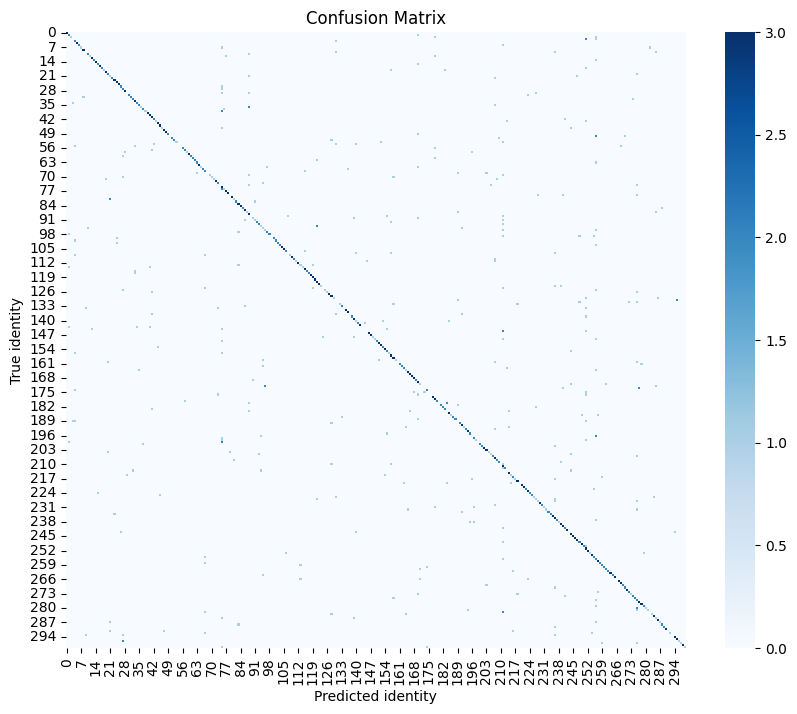

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

# confusion matrix (may be large with many identities - shown as a heatmap)
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap='Blues', cbar=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted identity')
plt.ylabel('True identity')
plt.show()


## 9. Plot training curves


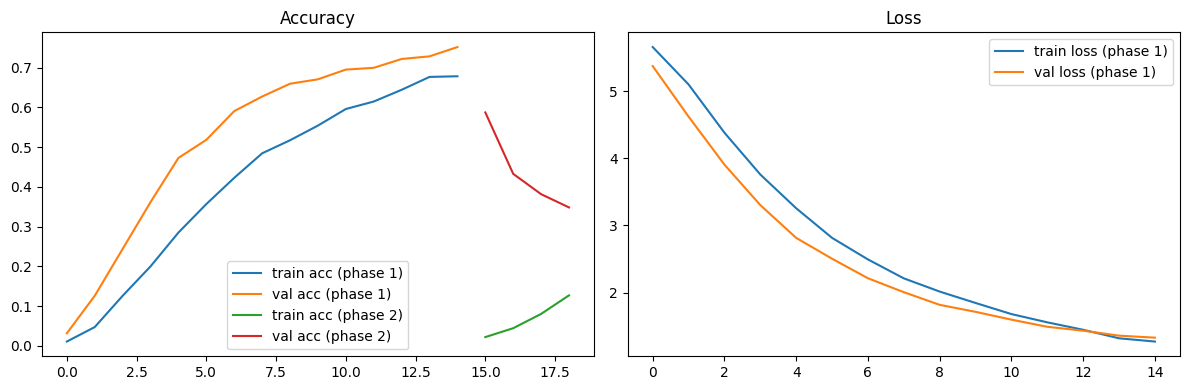

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train acc (phase 1)')
plt.plot(history.history['val_accuracy'], label='val acc (phase 1)')
if 'history_fine' in dir():
    offset = len(history.history['accuracy'])
    plt.plot(range(offset, offset+len(history_fine.history['accuracy'])),
             history_fine.history['accuracy'], label='train acc (phase 2)')
    plt.plot(range(offset, offset+len(history_fine.history['val_accuracy'])),
             history_fine.history['val_accuracy'], label='val acc (phase 2)')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss (phase 1)')
plt.plot(history.history['val_loss'], label='val loss (phase 1)')
plt.legend()
plt.title('Loss')

plt.tight_layout()
plt.show()


## 10. Save the trained model


In [11]:
model.save('/content/drive/MyDrive/palm_project/mobilenetv2_palm_model.h5')
print("Model saved to Drive.")


Model saved to Drive.
